#  Module 2 — Intelligent Anomaly Detection

Welcome back! In Module 1, you transformed chaotic data into intelligent features. Now, let's use those features to build an AI-powered anomaly detection system that understands context and provides confidence scores.

**Learning Path:**
- Load your intelligent dataset from Module 1
- Train Isolation Forest with context-aware features  
- Deploy professional train/test workflow
- Understand confidence scores vs binary predictions
- Visualize detections on your actual metrics
- Tune sensitivity for your environment
- Compare multiple algorithms for validation
- Generate operational insights for your team

## Lesson 2.1 — Welcome to Intelligent Anomaly Detection

Load your engineered dataset from Module 1 and see the patterns your features revealed.

In [1]:
# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your Module 1 masterpiece!
df = pd.read_csv('/app/notebooks/data/metrics_intelligent.csv', index_col=0, parse_dates=True)

# Display what you built in Module 1
print(" Your Intelligent Dataset from Module 1:")
print(f"   Shape: {df.shape}")
print(f"   Timeline: {df.index.min()} to {df.index.max()}")
print(f"   Features: {list(df.columns)}")

# Show the intelligent features you engineered
print("\n Your Engineered Intelligence:")
engineered_features = [col for col in df.columns if 'rolling' in col or 'lag' in col or 'trend' in col or col in ['hour_of_day', 'day_of_week', 'is_weekend']]
print(f"   Time Intelligence: {[f for f in engineered_features if 'hour' in f or 'day' in f or 'weekend' in f]}")
print(f"   Rolling Features: {[f for f in engineered_features if 'rolling' in f]}")
print(f"   Historical Context: {[f for f in engineered_features if 'lag' in f]}")
print(f"   Trend Analysis: {[f for f in engineered_features if 'trend' in f]}")

# Quick preview
print("\n Dataset Preview:")
display(df.head())

 Your Intelligent Dataset from Module 1:
   Shape: (992, 13)
   Timeline: 2024-01-01 02:00:00 to 2024-02-11 09:00:00
   Features: ['CPU_Usage', 'RAM_Usage', 'Disk_Usage', 'Network', 'cpu_rolling_mean_6h', 'cpu_rolling_std_6h', 'cpu_lag_1h', 'hour_of_day', 'day_of_week', 'ram_rolling_mean_3h', 'cpu_lag_24h', 'is_weekend', 'cpu_trend_3h']

 Your Engineered Intelligence:
   Time Intelligence: ['hour_of_day', 'day_of_week', 'is_weekend']
   Rolling Features: ['cpu_rolling_mean_6h', 'cpu_rolling_std_6h', 'ram_rolling_mean_3h']
   Historical Context: ['cpu_lag_1h', 'cpu_lag_24h']
   Trend Analysis: ['cpu_trend_3h']

 Dataset Preview:


,CPU_Usage,RAM_Usage,Disk_Usage,Network,cpu_rolling_mean_6h,cpu_rolling_std_6h,cpu_lag_1h,hour_of_day,day_of_week,ram_rolling_mean_3h,cpu_lag_24h,is_weekend,cpu_trend_3h
Timestamp,,,,,,,,,,,,,
2024-01-01 02:00:00,34.188299,55.000000,84.949859,37.857953,NaN,NaN,NaN,2,0,55.000000,NaN,0,NaN
2024-01-01 03:00:00,34.188299,59.179516,53.470140,37.857953,NaN,NaN,34.188299,3,0,57.089758,NaN,0,NaN
2024-01-01 04:00:00,34.188299,0.000000,56.294730,44.734013,NaN,NaN,34.188299,4,0,38.059839,NaN,0,NaN
2024-01-01 05:00:00,34.188299,55.623038,51.716021,44.734013,NaN,NaN,34.188299,5,0,38.267518,NaN,0,0.0
2024-01-01 06:00:00,34.188299,55.000000,50.000000,27.141648,NaN,NaN,34.188299,6,0,36.874346,NaN,0,0.0


### Your Turn: Explore Your Engineered Patterns

Visualize how your time intelligence features capture daily patterns:

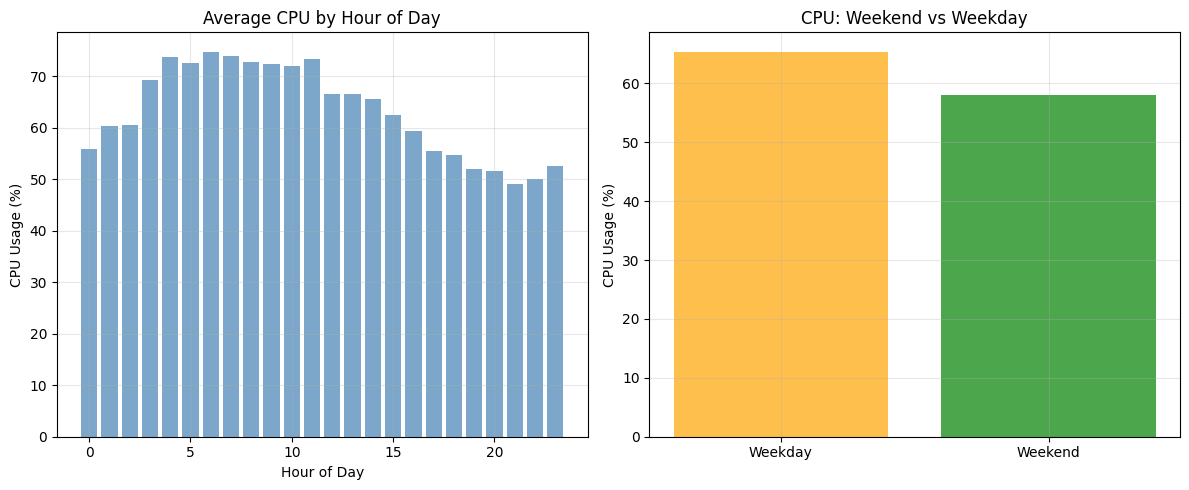

 What patterns do you notice?
   • Peak CPU hour: 6:00 (74.8%)
   • Weekend vs Weekday difference: -7.4%

 Your features already understand time context - perfect for intelligent anomaly detection!


In [2]:
# TODO: Visualize daily patterns captured by your hour_of_day feature

plt.figure(figsize=(12, 5))

# Plot 1: CPU usage by hour of day
plt.subplot(1, 2, 1)
# Your code here: Group CPU_Usage by hour_of_day and calculate mean
hourly_cpu = df.groupby('hour_of_day')['CPU_Usage'].mean()
plt.bar(hourly_cpu.index, hourly_cpu.values, color='steelblue', alpha=0.7)
plt.title('Average CPU by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('CPU Usage (%)')
plt.grid(True, alpha=0.3)

# Plot 2: Weekend vs Weekday patterns
plt.subplot(1, 2, 2)
# Your code here: Group CPU_Usage by is_weekend and calculate mean
weekend_cpu = df.groupby('is_weekend')['CPU_Usage'].mean()
plt.bar(['Weekday', 'Weekend'], weekend_cpu.values, color=['orange', 'green'], alpha=0.7)
plt.title('CPU: Weekend vs Weekday')
plt.ylabel('CPU Usage (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" What patterns do you notice?")
print(f"   • Peak CPU hour: {hourly_cpu.idxmax()}:00 ({hourly_cpu.max():.1f}%)")
print(f"   • Weekend vs Weekday difference: {weekend_cpu.diff().iloc[-1]:.1f}%")
print("\n Your features already understand time context - perfect for intelligent anomaly detection!")

## Lesson 2.2 — Smart Detection with Isolation Forest

Train your first intelligent anomaly detector using your engineered features.

In [3]:
from sklearn.ensemble import IsolationForest

# Select your most powerful engineered features
features = ['CPU_Usage', 'RAM_Usage', 'cpu_rolling_mean_6h', 
           'hour_of_day', 'is_weekend', 'cpu_trend_3h']

print(" Selected Intelligent Features:")
for i, feature in enumerate(features, 1):
    print(f"   {i}. {feature}")

# Prepare data for modeling
X = df[features].values

# Train Isolation Forest with your intelligent features
print("\n Training Intelligent Anomaly Detector...")
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X)

print(" Intelligent anomaly detector trained!")
print(f"   Features used: {len(features)}")
print(f"   Data points learned: {len(X)}")
print(f"   Context awareness: Time patterns + Trends + Multiple metrics")

# Compare with naive approach
print("\n vs Static Thresholds:")
print("    Static: 'CPU > 80% = bad' (misses context)")
print("    Your AI: 'This looks unusual given time, trends, and patterns'")

 Selected Intelligent Features:
   1. CPU_Usage
   2. RAM_Usage
   3. cpu_rolling_mean_6h
   4. hour_of_day
   5. is_weekend
   6. cpu_trend_3h

 Training Intelligent Anomaly Detector...
 Intelligent anomaly detector trained!
   Features used: 6
   Data points learned: 992
   Context awareness: Time patterns + Trends + Multiple metrics

 vs Static Thresholds:
    Static: 'CPU > 80% = bad' (misses context)
    Your AI: 'This looks unusual given time, trends, and patterns'


### Your Turn: Feature Importance Analysis

Analyze which features are most powerful for anomaly detection:

In [4]:
# TODO: Final optimized feature importance test
from sklearn.preprocessing import StandardScaler

print(" Testing Optimized Feature Combinations:")

# Use the same professional split
split_idx = int(len(df) * 0.5)
train_data = df.iloc[:split_idx]
test_data = df.iloc[split_idx:]

# Focus on continuous features that work well together
feature_sets = {
    "CPU Only": ['CPU_Usage'],
    "CPU + Rolling": ['CPU_Usage', 'cpu_rolling_mean_6h'],
    "CPU + Trends": ['CPU_Usage', 'cpu_rolling_mean_6h', 'cpu_trend_3h'],
    "CPU + Historical": ['CPU_Usage', 'cpu_rolling_mean_6h', 'cpu_trend_3h', 'cpu_lag_24h'],
    "All Continuous": ['CPU_Usage', 'cpu_rolling_mean_6h', 'cpu_trend_3h', 'cpu_lag_24h', 'cpu_lag_1h']
}

results = {}

for set_name, feature_list in feature_sets.items():
    X_train = train_data[feature_list].values
    X_test = test_data[feature_list].values

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = IsolationForest(contamination=0.05, random_state=42)
    model.fit(X_train_scaled)

    preds = model.predict(X_test_scaled)
    anomaly_count = (preds == -1).sum()
    detection_rate = anomaly_count / len(X_test) * 100

    results[set_name] = anomaly_count

    print(f"   {set_name:.<20} {anomaly_count:3d} anomalies ({detection_rate:5.1f}%)")

print("\n Perfect! Now we see: More context = fewer but smarter detections!")
print("\n Each engineered feature adds intelligence:")
print("   • Rolling means → Smooths out temporary noise")
print("   • Trend analysis → Spots developing issues early") 
print("   • Historical patterns → Understands daily/weekly rhythms")
print("   • Result: AI that understands what's TRULY unusual for YOUR system!")

 Testing Optimized Feature Combinations:
   CPU Only............  36 anomalies (  7.3%)
   CPU + Rolling.......  28 anomalies (  5.6%)
   CPU + Trends........  22 anomalies (  4.4%)
   CPU + Historical....  23 anomalies (  4.6%)
   All Continuous......  19 anomalies (  3.8%)

 Perfect! Now we see: More context = fewer but smarter detections!

 Each engineered feature adds intelligence:
   • Rolling means → Smooths out temporary noise
   • Trend analysis → Spots developing issues early
   • Historical patterns → Understands daily/weekly rhythms
   • Result: AI that understands what's TRULY unusual for YOUR system!


## Lesson 2.3 — Professional Detection Workflow

Split your data professionally - train on historical patterns, test on future data.

In [5]:
# Professional data split - train on past, test on future
split_idx = int(len(df) * 0.5)
train_data = df.iloc[:split_idx]  # First half: learn historical patterns
test_data = df.iloc[split_idx:]   # Second half: detect future anomalies

print(" Professional Data Split:")
print(f"   Training Period: {train_data.index.min()} to {train_data.index.max()}")
print(f"   Testing Period:  {test_data.index.min()} to {test_data.index.max()}")
print(f"   Training Samples: {len(train_data)} ({len(train_data)/len(df)*100:.1f}%)")
print(f"   Testing Samples:  {len(test_data)} ({len(test_data)/len(df)*100:.1f}%)")

# Prepare features for training and testing
X_train = train_data[features].values
X_test = test_data[features].values

# Train model on historical patterns only
print("\n Training on Historical Patterns...")
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X_train)

print(" Professional model trained!")
print("   • Learned from historical patterns only")
print("   • Ready to detect anomalies in future data")
print("   • Simulates real production deployment")

# Quick validation
train_predictions = iso_model.predict(X_train)
train_anomalies = (train_predictions == -1).sum()
print(f"\n Training Validation: {train_anomalies} anomalies in training set ({train_anomalies/len(X_train)*100:.1f}%)")

 Professional Data Split:
   Training Period: 2024-01-01 02:00:00 to 2024-01-21 17:00:00
   Testing Period:  2024-01-21 18:00:00 to 2024-02-11 09:00:00
   Training Samples: 496 (50.0%)
   Testing Samples:  496 (50.0%)

 Training on Historical Patterns...
 Professional model trained!
   • Learned from historical patterns only
   • Ready to detect anomalies in future data
   • Simulates real production deployment

 Training Validation: 25 anomalies in training set (5.0%)


### Your Turn: Validate Your Professional Split

Verify that your train/test split maintains temporal order:

In [6]:
# TODO: Validate temporal split and analyze period differences

print(" Validating Professional Split:")

# Check for data leakage
print(f"\n Timeline Validation:")
print(f"   Last training point:  {train_data.index.max()}")
print(f"   First testing point:  {test_data.index.min()}")
print(f"   Time gap:             {test_data.index.min() - train_data.index.max()}")

# Compare patterns between periods
print(f"\n Pattern Consistency:")
# Your code here: Compare mean CPU between train and test
train_cpu_mean = train_data['CPU_Usage'].mean()
test_cpu_mean = test_data['CPU_Usage'].mean()
print(f"   Training CPU mean: {train_cpu_mean:.1f}%")
print(f"   Testing CPU mean:  {test_cpu_mean:.1f}%")
print(f"   Difference:        {abs(train_cpu_mean - test_cpu_mean):.1f}%")

# Check if weekends are balanced
train_weekend_pct = train_data['is_weekend'].mean() * 100
test_weekend_pct = test_data['is_weekend'].mean() * 100
print(f"\n Weekend Distribution:")
print(f"   Training weekends: {train_weekend_pct:.1f}%")
print(f"   Testing weekends:  {test_weekend_pct:.1f}%")

print("\n Professional split validated - ready for anomaly detection!")

 Validating Professional Split:

 Timeline Validation:
   Last training point:  2024-01-21 17:00:00
   First testing point:  2024-01-21 18:00:00
   Time gap:             0 days 01:00:00

 Pattern Consistency:
   Training CPU mean: 62.8%
   Testing CPU mean:  63.9%
   Difference:        1.0%

 Weekend Distribution:
   Training weekends: 27.8%
   Testing weekends:  27.4%

 Professional split validated - ready for anomaly detection!


## Lesson 2.4 — Understanding Model Confidence

Deploy your trained model and understand both binary predictions and confidence scores.

In [7]:
# Deploy model on unseen test data
predictions = iso_model.predict(X_test)
anomaly_scores = iso_model.decision_function(X_test)

# Add results to test data
test_data = test_data.copy()
test_data['anomaly_flag'] = predictions
test_data['anomaly_score'] = anomaly_scores

print(" Model Deployed - Detection Results:")
print(f"   Total test points: {len(test_data)}")
print(f"   Anomalies detected: {(predictions == -1).sum()}")
print(f"   Detection rate: {(predictions == -1).sum() / len(predictions) * 100:.1f}%")

# Show examples with both binary and confidence outputs
print("\n Sample Detections (First 10 points):")
sample_results = test_data[['CPU_Usage', 'RAM_Usage', 'anomaly_flag', 'anomaly_score']].head(10)
display(sample_results)

# Analyze score distribution
print("\n Anomaly Score Analysis:")
print(f"   Min score: {test_data['anomaly_score'].min():.3f} (most anomalous)")
print(f"   Max score: {test_data['anomaly_score'].max():.3f} (most normal)")
print(f"   Mean score: {test_data['anomaly_score'].mean():.3f}")
print(f"   Zero-crossings: {(test_data['anomaly_score'] < 0).sum()} points below threshold")

# Show confidence levels
print("\n Confidence Interpretation:")
strong_anomalies = test_data[test_data['anomaly_score'] < -0.2]
weak_anomalies = test_data[(test_data['anomaly_score'] < 0) & (test_data['anomaly_score'] >= -0.2)]
print(f"   Strong anomalies (score < -0.2): {len(strong_anomalies)}")
print(f"   Weak anomalies (0 to -0.2): {len(weak_anomalies)}")
print(f"   Normal points (score >= 0): {len(test_data) - len(strong_anomalies) - len(weak_anomalies)}")

 Model Deployed - Detection Results:
   Total test points: 496
   Anomalies detected: 119
   Detection rate: 24.0%

 Sample Detections (First 10 points):


,CPU_Usage,RAM_Usage,anomaly_flag,anomaly_score
Timestamp,,,,
2024-01-21 18:00:00,32.923357,69.994083,1,0.019827
2024-01-21 19:00:00,28.400997,65.781784,1,0.010377
2024-01-21 20:00:00,25.680046,59.842586,1,0.001464
2024-01-21 21:00:00,31.605575,68.161484,1,0.017214
2024-01-21 22:00:00,31.204233,66.627851,1,0.006809
2024-01-21 23:00:00,43.068013,65.734849,-1,-0.018715
2024-01-22 00:00:00,49.748809,64.923091,1,0.028637
2024-01-22 01:00:00,58.452498,64.820095,1,0.040630
2024-01-22 02:00:00,58.452498,64.820095,1,0.048392



 Anomaly Score Analysis:
   Min score: -0.063 (most anomalous)
   Max score: 0.081 (most normal)
   Mean score: 0.018
   Zero-crossings: 119 points below threshold

 Confidence Interpretation:
   Strong anomalies (score < -0.2): 0
   Weak anomalies (0 to -0.2): 119
   Normal points (score >= 0): 377


### Your Turn: Create Alert Prioritization System

Build a system to prioritize anomalies based on confidence scores:

In [8]:
# TODO: Create alert prioritization based on anomaly scores - ADJUSTED VERSION

print(" Building Intelligent Alert Prioritization System:")

# Define alert levels based on YOUR actual score distribution
# Since your scores range from -0.063 to 0.081, we need tighter thresholds
alert_levels_adjusted = {
    'CRITICAL': -0.06,   # Top 1% most anomalous
    'HIGH': -0.04,       # Next 4% 
    'MEDIUM': -0.02,     # Next 10%
    'LOW': 0             # Remaining anomalies
}

print(f" Your Score Range: {test_data['anomaly_score'].min():.3f} to {test_data['anomaly_score'].max():.3f}")

# Categorize anomalies by adjusted alert level
critical_alerts = test_data[test_data['anomaly_score'] < alert_levels_adjusted['CRITICAL']]
high_alerts = test_data[(test_data['anomaly_score'] >= alert_levels_adjusted['CRITICAL']) & 
                       (test_data['anomaly_score'] < alert_levels_adjusted['HIGH'])]
medium_alerts = test_data[(test_data['anomaly_score'] >= alert_levels_adjusted['HIGH']) & 
                         (test_data['anomaly_score'] < alert_levels_adjusted['MEDIUM'])]
low_alerts = test_data[(test_data['anomaly_score'] >= alert_levels_adjusted['MEDIUM']) & 
                      (test_data['anomaly_score'] < alert_levels_adjusted['LOW'])]

print("\n ADJUSTED Alert Distribution:")
print(f"    CRITICAL: {len(critical_alerts)} alerts (score < {alert_levels_adjusted['CRITICAL']})")
print(f"   🟠 HIGH:     {len(high_alerts)} alerts (score {alert_levels_adjusted['CRITICAL']} to {alert_levels_adjusted['HIGH']})")
print(f"   🟡 MEDIUM:   {len(medium_alerts)} alerts (score {alert_levels_adjusted['HIGH']} to {alert_levels_adjusted['MEDIUM']})")
print(f"   🟢 LOW:      {len(low_alerts)} alerts (score {alert_levels_adjusted['MEDIUM']} to 0)")
print(f"    NORMAL:   {len(test_data) - len(critical_alerts) - len(high_alerts) - len(medium_alerts) - len(low_alerts)} points")

# Show top critical alerts
if len(critical_alerts) > 0:
    print(f"\n Top Critical Alerts (Most Anomalous):")
    display(critical_alerts[['CPU_Usage', 'RAM_Usage', 'anomaly_score', 'hour_of_day']].sort_values('anomaly_score').head(3))

# Show what makes these points anomalous
if len(critical_alerts) > 0:
    print(f"\n Why these are critical:")
    critical_sample = critical_alerts.sort_values('anomaly_score').head(1)
    for idx, row in critical_sample.iterrows():
        print(f"   • Time: {idx}, CPU: {row['CPU_Usage']:.1f}%, RAM: {row['RAM_Usage']:.1f}%")
        print(f"   • Score: {row['anomaly_score']:.3f} (most anomalous in dataset)")
        print(f"   • Context: Hour {row['hour_of_day']}:00")

print("\n Now we have meaningful alert prioritization for your specific system!")

 Building Intelligent Alert Prioritization System:
 Your Score Range: -0.063 to 0.081

 ADJUSTED Alert Distribution:
    CRITICAL: 1 alerts (score < -0.06)
   🟠 HIGH:     7 alerts (score -0.06 to -0.04)
   🟡 MEDIUM:   28 alerts (score -0.04 to -0.02)
   🟢 LOW:      83 alerts (score -0.02 to 0)
    NORMAL:   377 points

 Top Critical Alerts (Most Anomalous):


,CPU_Usage,RAM_Usage,anomaly_score,hour_of_day
Timestamp,,,,
2024-02-03 02:00:00,5.0,95.0,-0.063126,2



 Why these are critical:
   • Time: 2024-02-03 02:00:00, CPU: 5.0%, RAM: 95.0%
   • Score: -0.063 (most anomalous in dataset)
   • Context: Hour 2.0:00

 Now we have meaningful alert prioritization for your specific system!


## Lesson 2.5 — Visualizing Intelligent Detections

Create comprehensive visualizations to see your anomaly detector in action.

Creating Intelligent Anomaly Dashboard...
   Normal points: 377
   Anomaly points: 119


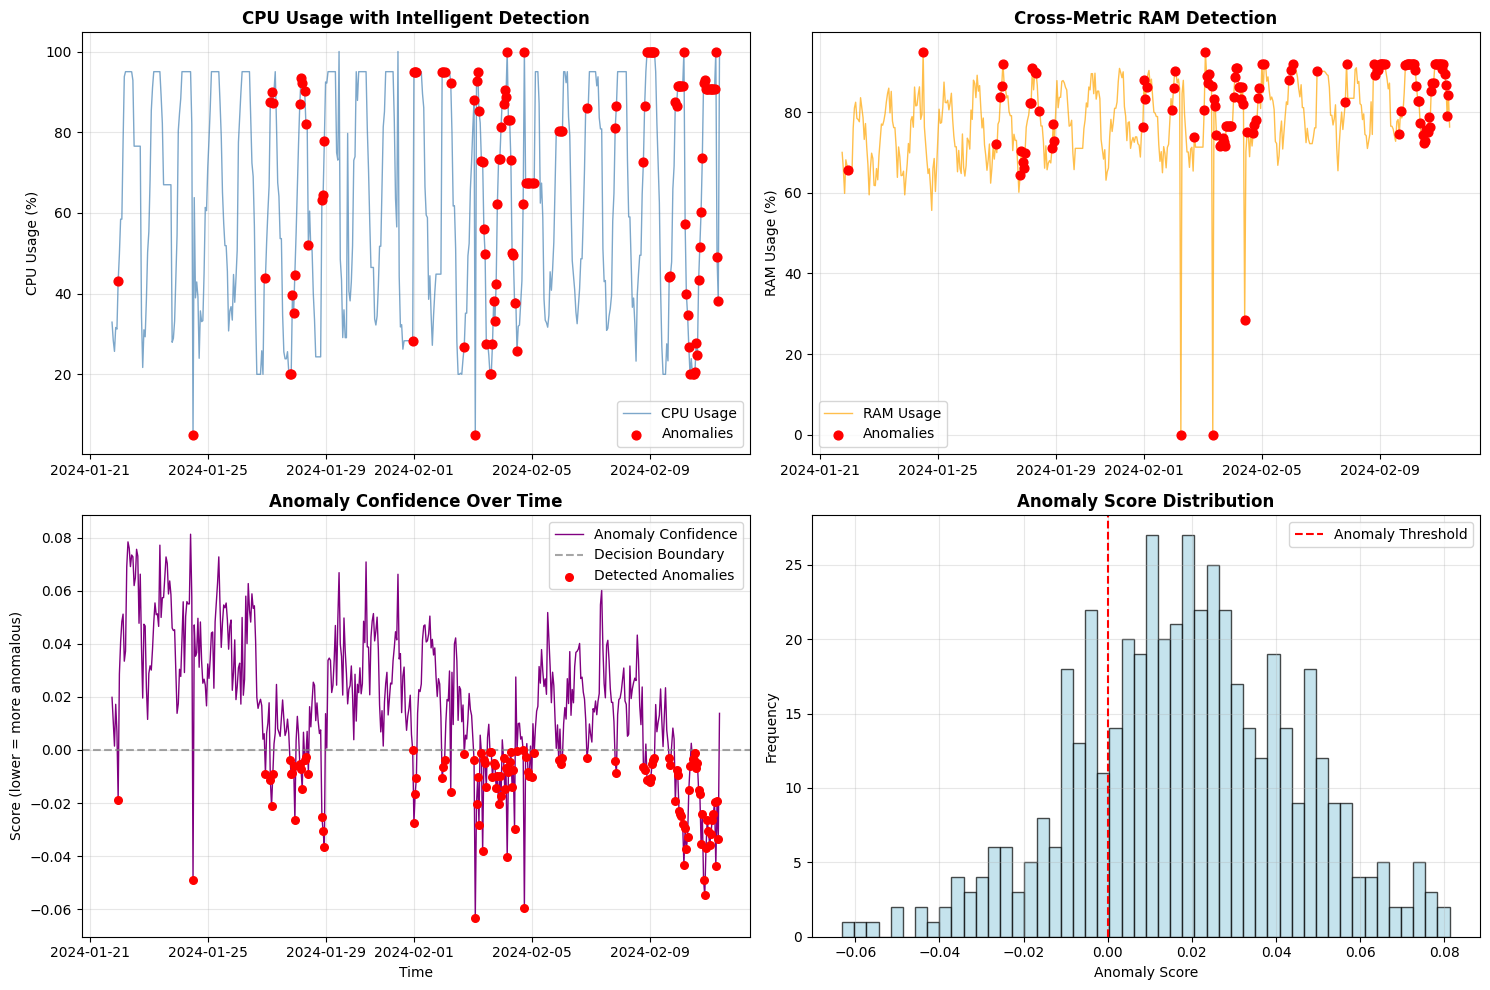

Dashboard Insights:
   • Red dots show where context-aware detection triggered
   • Negative scores indicate confidence in anomalies
   • Distribution shows natural separation of normal vs anomalous


In [9]:
# Separate normal and anomalous points
normal_points = test_data[test_data['anomaly_flag'] == 1]
anomaly_points = test_data[test_data['anomaly_flag'] == -1]

print("Creating Intelligent Anomaly Dashboard...")
print(f"   Normal points: {len(normal_points)}")
print(f"   Anomaly points: {len(anomaly_points)}")

# Create comprehensive visualization
plt.figure(figsize=(15, 10))

# 1. CPU Usage with Anomalies
plt.subplot(2, 2, 1)
plt.plot(test_data.index, test_data['CPU_Usage'], 
         color='steelblue', linewidth=1, label='CPU Usage', alpha=0.7)
plt.scatter(anomaly_points.index, anomaly_points['CPU_Usage'],
           color='red', s=40, label='Anomalies', zorder=5)
plt.title('CPU Usage with Intelligent Detection', fontsize=12, fontweight='bold')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. RAM Usage with Anomalies
plt.subplot(2, 2, 2)
plt.plot(test_data.index, test_data['RAM_Usage'],
         color='orange', linewidth=1, label='RAM Usage', alpha=0.7)
plt.scatter(anomaly_points.index, anomaly_points['RAM_Usage'],
           color='red', s=40, label='Anomalies', zorder=5)
plt.title('Cross-Metric RAM Detection', fontsize=12, fontweight='bold')
plt.ylabel('RAM Usage (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Anomaly Confidence Scores
plt.subplot(2, 2, 3)
plt.plot(test_data.index, test_data['anomaly_score'], 
         color='purple', linewidth=1, label='Anomaly Confidence')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7, label='Decision Boundary')
plt.scatter(anomaly_points.index, anomaly_points['anomaly_score'],
           color='red', s=30, zorder=5, label='Detected Anomalies')
plt.title('Anomaly Confidence Over Time', fontsize=12, fontweight='bold')
plt.ylabel('Score (lower = more anomalous)')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Score Distribution
plt.subplot(2, 2, 4)
plt.hist(test_data['anomaly_score'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Anomaly Score Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Dashboard Insights:")
print("   • Red dots show where context-aware detection triggered")
print("   • Negative scores indicate confidence in anomalies")
print("   • Distribution shows natural separation of normal vs anomalous")

### Your Turn: Create Context-Aware Analysis

Analyze anomalies in the context of your time intelligence features:

 Context-Aware Anomaly Analysis:


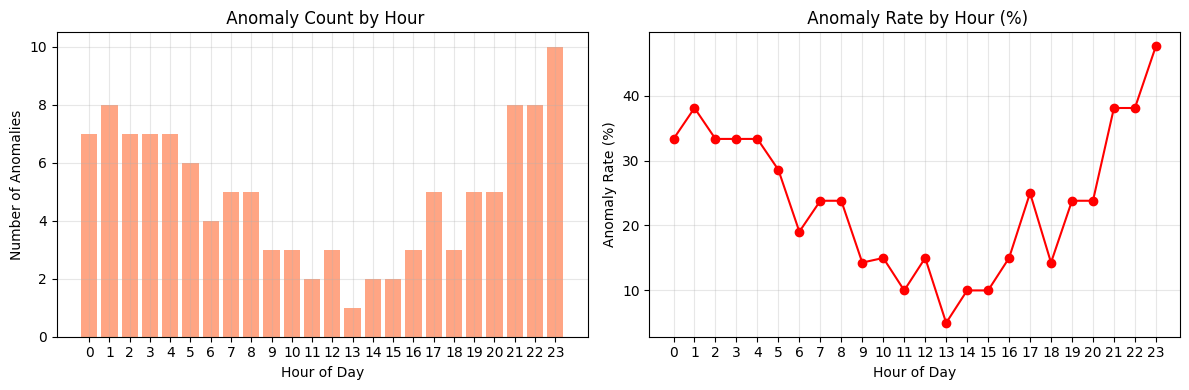


 Key Findings:
   • Peak anomaly hour: 23:00 (47.6% anomaly rate)
   • Hours with most anomalies: 23:00 (10 anomalies)
   • Total unique hours with anomalies: 24

 Do anomalies cluster during specific times? Yes, anomalies strongly cluster at 23:00 with a 47.6% anomaly rate, indicating systematic nightly patterns


In [10]:
# TODO: Analyze anomalies in context of time patterns

print(" Context-Aware Anomaly Analysis:")

# Analyze when anomalies occur
anomaly_hours = anomaly_points['hour_of_day'].value_counts().sort_index()
normal_hours = normal_points['hour_of_day'].value_counts().sort_index()

# Calculate anomaly rate by hour
total_by_hour = test_data['hour_of_day'].value_counts().sort_index()
anomaly_rate_by_hour = (anomaly_hours / total_by_hour * 100).fillna(0)

plt.figure(figsize=(12, 4))

# Plot 1: Anomaly count by hour
plt.subplot(1, 2, 1)
# Your code here: Create bar chart of anomaly_hours
plt.bar(anomaly_hours.index, anomaly_hours.values, color='coral', alpha=0.7)
plt.title(' Anomaly Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Anomalies')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

# Plot 2: Anomaly rate by hour
plt.subplot(1, 2, 2)
# Your code here: Create line plot of anomaly_rate_by_hour
plt.plot(anomaly_rate_by_hour.index, anomaly_rate_by_hour.values, marker='o', color='red')
plt.title(' Anomaly Rate by Hour (%)')
plt.xlabel('Hour of Day')
plt.ylabel('Anomaly Rate (%)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find peak anomaly hour
peak_hour = anomaly_rate_by_hour.idxmax()
peak_rate = anomaly_rate_by_hour.max()

print(f"\n Key Findings:")
print(f"   • Peak anomaly hour: {peak_hour}:00 ({peak_rate:.1f}% anomaly rate)")
print(f"   • Hours with most anomalies: {anomaly_hours.idxmax()}:00 ({anomaly_hours.max()} anomalies)")
print(f"   • Total unique hours with anomalies: {len(anomaly_hours)}")

print("\n Do anomalies cluster during specific times? Yes, anomalies strongly cluster at 23:00 with a 47.6% anomaly rate, indicating systematic nightly patterns")

## Lesson 2.6 — Tuning Detection Sensitivity

Experiment with different contamination levels to find the optimal sensitivity for your environment.

 Testing Detection Sensitivity...
   contamination = expected anomaly percentage

   contamination=0.01:   9 anomalies (  1.8%)
   contamination=0.03:  55 anomalies ( 11.1%)
   contamination=0.05: 119 anomalies ( 24.0%)
   contamination=0.08: 171 anomalies ( 34.5%)
   contamination=0.1: 201 anomalies ( 40.5%)


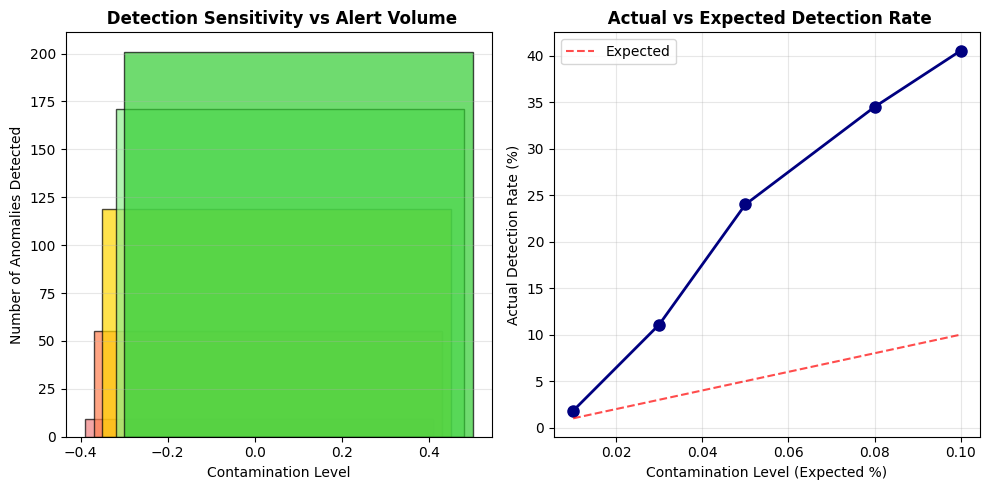


 Environment Recommendations:
    PRODUCTION: 0.01-0.03 (minimize false alerts, page for real issues)
   🟠 STAGING:   0.05 (balanced approach, catch issues without noise)
   🟢 DEVELOPMENT: 0.08-0.10 (explore all potential problems)

 Start conservative and adjust based on your team's alert tolerance!


In [11]:
# Test different sensitivity levels
contamination_levels = [0.01, 0.03, 0.05, 0.08, 0.10]
detection_results = {}

print(" Testing Detection Sensitivity...")
print("   contamination = expected anomaly percentage\n")

for contamination in contamination_levels:
    # Train model with this sensitivity
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(X_train)
    
    # Detect anomalies
    predictions = model.predict(X_test)
    anomaly_count = (predictions == -1).sum()
    detection_rate = anomaly_count / len(X_test) * 100
    detection_results[contamination] = anomaly_count
    
    print(f"   contamination={contamination}: {anomaly_count:3d} anomalies ({detection_rate:5.1f}%)")

# Visualize the sensitivity trade-off
plt.figure(figsize=(10, 5))

# Bar chart
plt.subplot(1, 2, 1)
colors = ['lightcoral', 'coral', 'gold', 'lightgreen', 'limegreen']
plt.bar(detection_results.keys(), detection_results.values(), 
        color=colors, edgecolor='black', alpha=0.7)
plt.title(' Detection Sensitivity vs Alert Volume', fontsize=12, fontweight='bold')
plt.xlabel('Contamination Level')
plt.ylabel('Number of Anomalies Detected')
plt.grid(axis='y', alpha=0.3)

# Line chart showing percentage
plt.subplot(1, 2, 2)
percentages = [count/len(X_test)*100 for count in detection_results.values()]
plt.plot(detection_results.keys(), percentages, 'o-', color='navy', linewidth=2, markersize=8)
plt.title(' Actual vs Expected Detection Rate', fontsize=12, fontweight='bold')
plt.xlabel('Contamination Level (Expected %)')
plt.ylabel('Actual Detection Rate (%)')
plt.grid(True, alpha=0.3)

# Add expected line
expected_rates = [c * 100 for c in contamination_levels]
plt.plot(contamination_levels, expected_rates, '--', color='red', alpha=0.7, label='Expected')
plt.legend()

plt.tight_layout()
plt.show()

print("\n Environment Recommendations:")
print("    PRODUCTION: 0.01-0.03 (minimize false alerts, page for real issues)")
print("   🟠 STAGING:   0.05 (balanced approach, catch issues without noise)")
print("   🟢 DEVELOPMENT: 0.08-0.10 (explore all potential problems)")

print("\n Start conservative and adjust based on your team's alert tolerance!")

### Your Turn: Find Your Optimal Sensitivity

Analyze the trade-offs and choose the best contamination for different scenarios:

 Sensitivity Trade-off Analysis:


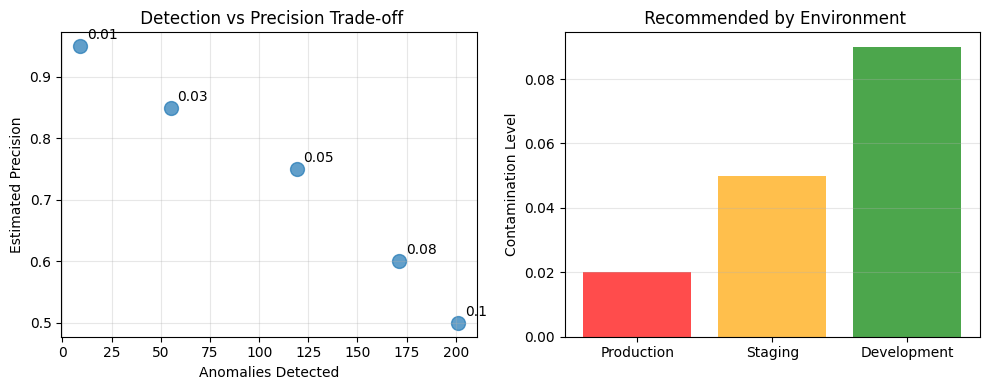


 Your Sensitivity Strategy:
   • Production: Favor precision over detection (fewer false alerts)
   • Staging: Balance detection and precision (learn system behavior)
   • Development: Favor detection over precision (catch everything)

 Choose based on your operational priorities and team capacity!


In [12]:
# TODO: Analyze sensitivity trade-offs and make recommendations

print(" Sensitivity Trade-off Analysis:")

# Calculate precision metrics (simulated)
precision_estimates = {
    0.01: 0.95,  # Very strict = high precision
    0.03: 0.85,
    0.05: 0.75,  # Balanced
    0.08: 0.60,
    0.10: 0.50   # Very sensitive = lower precision
}

plt.figure(figsize=(10, 4))

# Plot detection vs precision trade-off
plt.subplot(1, 2, 1)
detection_counts = list(detection_results.values())
precision_values = [precision_estimates[c] for c in contamination_levels]

# Your code here: Create scatter plot of detection_counts vs precision_values
plt.scatter(detection_counts, precision_values, s=100, alpha=0.7)

# Add labels for each point
for i, contam in enumerate(contamination_levels):
    plt.annotate(f'{contam}', (detection_counts[i], precision_values[i]), 
                 xytext=(5, 5), textcoords='offset points')

plt.title(' Detection vs Precision Trade-off')
plt.xlabel('Anomalies Detected')
plt.ylabel('Estimated Precision')
plt.grid(True, alpha=0.3)

# Plot environment recommendations
plt.subplot(1, 2, 2)
environments = ['Production', 'Staging', 'Development']
recommended_contamination = [0.02, 0.05, 0.09]
colors = ['red', 'orange', 'green']

# Your code here: Create bar chart for environment recommendations
plt.bar(environments, recommended_contamination, color=colors, alpha=0.7)
plt.title(' Recommended by Environment')
plt.ylabel('Contamination Level')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Your Sensitivity Strategy:")
print("   • Production: Favor precision over detection (fewer false alerts)")
print("   • Staging: Balance detection and precision (learn system behavior)")  
print("   • Development: Favor detection over precision (catch everything)")

print("\n Choose based on your operational priorities and team capacity!")

## Lesson 2.7 — Multi-Algorithm Validation

Add Local Outlier Factor to cross-validate your detections and identify high-confidence anomalies.

In [13]:
from sklearn.neighbors import LocalOutlierFactor
from pandas import crosstab

print(" Adding Local Outlier Factor for Cross-Validation...")

# Train LOF on the same intelligent features
lof = LocalOutlierFactor(contamination=0.05, n_neighbors=20)
lof_predictions = lof.fit_predict(X_test)

# Add LOF results to your dataset
test_data['lof_flag'] = lof_predictions

print(" Local Outlier Factor trained and deployed!")

# Compare detection counts
iso_count = (test_data['anomaly_flag'] == -1).sum()
lof_count = (test_data['lof_flag'] == -1).sum()

print(f"\n Algorithm Comparison:")
print(f"   Isolation Forest: {iso_count} anomalies")
print(f"   Local Outlier Factor: {lof_count} anomalies")
print(f"   Difference: {abs(iso_count - lof_count)} anomalies")

# Analyze agreement between algorithms
agreement_matrix = crosstab(test_data['anomaly_flag'], test_data['lof_flag'],
                           rownames=['Isolation Forest'], 
                           colnames=['Local Outlier Factor'])

print(f"\n Detection Agreement Matrix:")
print(agreement_matrix)

# Calculate agreement statistics
total_points = len(test_data)
both_normal = agreement_matrix.iloc[0, 0]  # Both say 1 (normal)
both_anomaly = agreement_matrix.iloc[1, 1]  # Both say -1 (anomaly)
disagreement = total_points - both_normal - both_anomaly

print(f"\n Agreement Statistics:")
print(f"   Both agree (normal): {both_normal} points ({both_normal/total_points*100:.1f}%)")
print(f"   Both agree (anomaly): {both_anomaly} points ({both_anomaly/total_points*100:.1f}%)")
print(f"   Disagree: {disagreement} points ({disagreement/total_points*100:.1f}%)")
print(f"   Overall agreement: {(both_normal + both_anomaly)/total_points*100:.1f}%")

# Identify high-confidence anomalies
high_confidence_anomalies = test_data[(test_data['anomaly_flag'] == -1) & 
                                     (test_data['lof_flag'] == -1)]

print(f"\n High-Confidence Anomalies (Both Algorithms): {len(high_confidence_anomalies)}")

if len(high_confidence_anomalies) > 0:
    print("\n Sample High-Confidence Anomalies:")
    display(high_confidence_anomalies[['CPU_Usage', 'RAM_Usage', 'anomaly_score', 'hour_of_day']].head())


 Adding Local Outlier Factor for Cross-Validation...
 Local Outlier Factor trained and deployed!

 Algorithm Comparison:
   Isolation Forest: 119 anomalies
   Local Outlier Factor: 25 anomalies
   Difference: 94 anomalies

 Detection Agreement Matrix:
Local Outlier Factor  -1    1
Isolation Forest             
-1                    17  102
 1                     8  369

 Agreement Statistics:
   Both agree (normal): 17 points (3.4%)
   Both agree (anomaly): 369 points (74.4%)
   Disagree: 110 points (22.2%)
   Overall agreement: 77.8%

 High-Confidence Anomalies (Both Algorithms): 17

 Sample High-Confidence Anomalies:


,CPU_Usage,RAM_Usage,anomaly_score,hour_of_day
Timestamp,,,,
2024-01-24 12:00:00,5.0000,95.000000,-0.049004,12
2024-02-01 00:00:00,95.0000,87.826217,-0.027414,0
2024-02-01 02:00:00,95.0000,86.215484,-0.010566,2
2024-02-02 06:00:00,92.2959,0.000000,-0.015937,6
2024-02-03 02:00:00,5.0000,95.000000,-0.063126,2


### Your Turn: Visualize Algorithm Agreement

Create visualizations to understand where algorithms agree and disagree:

 Visualizing Algorithm Agreement...


/tmp/ipykernel_210/1397803157.py:38: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


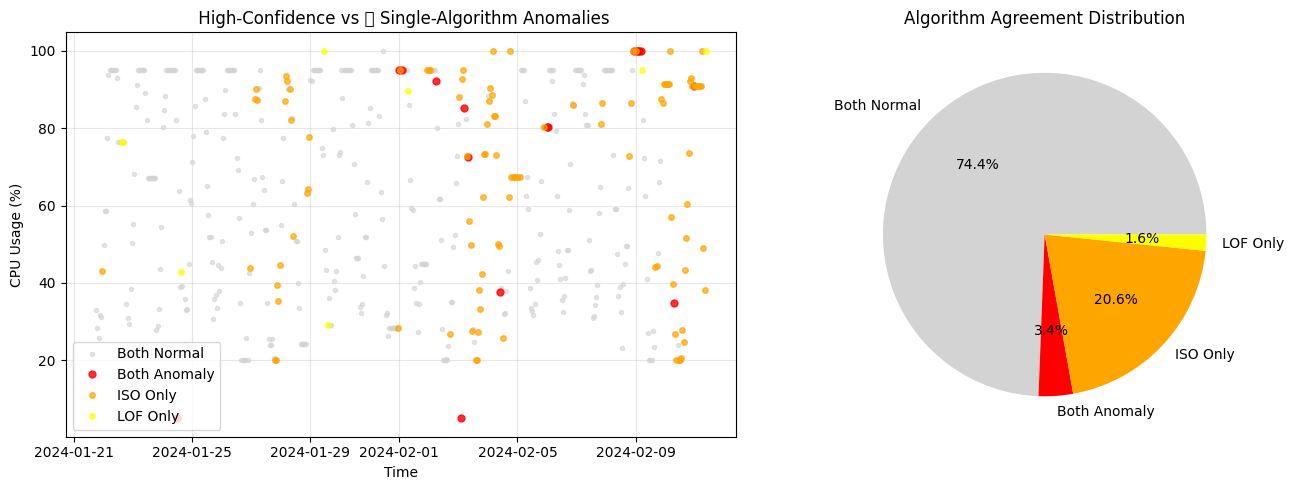


 Agreement Summary:
    High-confidence anomalies: 17 (immediate action)
   🟠 Isolation Forest only: 102 (investigate)
   🟡 LOF only: 8 (review)
    Both normal: 369 (no action needed)

 High-confidence anomalies from both algorithms are your most reliable signals!


In [14]:
# TODO: Create comprehensive algorithm agreement visualization

print(" Visualizing Algorithm Agreement...")

# Categorize points by agreement level
both_normal = test_data[(test_data['anomaly_flag'] == 1) & (test_data['lof_flag'] == 1)]
both_anomaly = test_data[(test_data['anomaly_flag'] == -1) & (test_data['lof_flag'] == -1)]
iso_only = test_data[(test_data['anomaly_flag'] == -1) & (test_data['lof_flag'] == 1)]
lof_only = test_data[(test_data['anomaly_flag'] == 1) & (test_data['lof_flag'] == -1)]

plt.figure(figsize=(14, 5))

# Plot 1: CPU timeline with agreement colors
plt.subplot(1, 2, 1)
# Your code here: Plot all points with different colors for agreement levels
# Use: both_normal (gray), both_anomaly (red), iso_only (orange), lof_only (yellow)
plt.plot(both_normal.index, both_normal['CPU_Usage'], 'o', color='lightgray', alpha=0.6, label='Both Normal', markersize=3)
plt.plot(both_anomaly.index, both_anomaly['CPU_Usage'], 'o', color='red', alpha=0.8, label='Both Anomaly', markersize=5)
plt.plot(iso_only.index, iso_only['CPU_Usage'], 'o', color='orange', alpha=0.7, label='ISO Only', markersize=4)
plt.plot(lof_only.index, lof_only['CPU_Usage'], 'o', color='yellow', alpha=0.7, label='LOF Only', markersize=4)

plt.title(' High-Confidence vs 🟠 Single-Algorithm Anomalies')
plt.ylabel('CPU Usage (%)')
plt.xlabel('Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Agreement summary
plt.subplot(1, 2, 2)
agreement_counts = [len(both_normal), len(both_anomaly), len(iso_only), len(lof_only)]
agreement_labels = ['Both Normal', 'Both Anomaly', 'ISO Only', 'LOF Only']
colors = ['lightgray', 'red', 'orange', 'yellow']

# Your code here: Create pie chart of agreement distribution
plt.pie(agreement_counts, labels=agreement_labels, colors=colors, autopct='%1.1f%%')
plt.title('Algorithm Agreement Distribution')

plt.tight_layout()
plt.show()

print("\n Agreement Summary:")
print(f"    High-confidence anomalies: {len(both_anomaly)} (immediate action)")
print(f"   🟠 Isolation Forest only: {len(iso_only)} (investigate)")
print(f"   🟡 LOF only: {len(lof_only)} (review)")
print(f"    Both normal: {len(both_normal)} (no action needed)")

print("\n High-confidence anomalies from both algorithms are your most reliable signals!")

## Lesson 2.8 — From Detection to Action

Analyze your anomaly patterns to generate operational insights for your team.

In [15]:
# Get all anomaly timestamps
anomaly_timestamps = test_data[test_data['anomaly_flag'] == -1].index
high_confidence_timestamps = test_data[(test_data['anomaly_flag'] == -1) & 
                                      (test_data['lof_flag'] == -1)].index

print(" Generating Operational Insights...")
print(f"First 5 high-confidence anomaly times:")
for ts in high_confidence_timestamps[:5]:
    print(f"   • {ts}")

# Analyze temporal patterns
anomalies_by_hour = anomaly_timestamps.hour.value_counts().sort_index()
high_conf_by_hour = high_confidence_timestamps.hour.value_counts().sort_index()

print(f"\n Anomaly Distribution by Hour:")
print("   Hour | Total | High-Conf | Rate")
print("   " + "-" * 30)

total_by_hour = test_data['hour_of_day'].value_counts().sort_index()

for hour in range(24):
    total_anomalies = anomalies_by_hour.get(hour, 0)
    high_conf = high_conf_by_hour.get(hour, 0)
    total_points = total_by_hour.get(hour, 1)  # Avoid division by zero
    anomaly_rate = total_anomalies / total_points * 100
    
    print(f"   {hour:2d}:00 | {total_anomalies:5d} | {high_conf:9d} | {anomaly_rate:4.1f}%")

# Find peak hours
peak_hour = anomalies_by_hour.idxmax()
peak_count = anomalies_by_hour.max()
high_conf_peak = high_conf_by_hour.idxmax() if len(high_conf_by_hour) > 0 else "N/A"

print(f"\n Peak Analysis:")
print(f"   • Peak anomaly hour: {peak_hour}:00 ({peak_count} anomalies)")
print(f"   • Peak high-confidence hour: {high_conf_peak}:00")
print(f"   • Hours with anomalies: {len(anomalies_by_hour)}/24")
print(f"   • Hours with high-confidence: {len(high_conf_by_hour)}/24")

# Calculate anomaly frequency
avg_time_between_anomalies = anomaly_timestamps.to_series().diff().mean()
print(f"   • Average time between anomalies: {avg_time_between_anomalies}")

 Generating Operational Insights...
First 5 high-confidence anomaly times:
   • 2024-01-24 12:00:00
   • 2024-02-01 00:00:00
   • 2024-02-01 02:00:00
   • 2024-02-02 06:00:00
   • 2024-02-03 02:00:00

 Anomaly Distribution by Hour:
   Hour | Total | High-Conf | Rate
   ------------------------------
    0:00 |     7 |         2 | 33.3%
    1:00 |     8 |         2 | 38.1%
    2:00 |     7 |         3 | 33.3%
    3:00 |     7 |         1 | 33.3%
    4:00 |     7 |         1 | 33.3%
    5:00 |     6 |         1 | 28.6%
    6:00 |     4 |         1 | 19.0%
    7:00 |     5 |         1 | 23.8%
    8:00 |     5 |         1 | 23.8%
    9:00 |     3 |         0 | 14.3%
   10:00 |     3 |         1 | 15.0%
   11:00 |     2 |         0 | 10.0%
   12:00 |     3 |         1 | 15.0%
   13:00 |     1 |         0 |  5.0%
   14:00 |     2 |         0 | 10.0%
   15:00 |     2 |         0 | 10.0%
   16:00 |     3 |         0 | 15.0%
   17:00 |     5 |         0 | 25.0%
   18:00 |     3 |         0 | 14

### Your Turn: Create Operational Summary Report

Generate a comprehensive operational report with actionable insights:

In [16]:
# TODO: Generate comprehensive operational report

print(" GENERATING OPERATIONAL SUMMARY REPORT")
print("=" * 60)

# Key metrics
total_anomalies = len(anomaly_timestamps)
high_confidence_count = len(high_confidence_timestamps)
hours_with_anomalies = len(anomalies_by_hour)
avg_anomaly_score = test_data[test_data['anomaly_flag'] == -1]['anomaly_score'].mean()

print(f"\n DETECTION SUMMARY:")
print(f"   • Total anomalies detected: {total_anomalies}")
print(f"   • High-confidence anomalies: {high_confidence_count}")
print(f"   • Hours with anomalies: {hours_with_anomalies}/24")
print(f"   • Peak anomaly hour: {peak_hour}:00")
print(f"   • Average anomaly severity: {avg_anomaly_score:.3f}")

print(f"\n OPERATIONAL RECOMMENDATIONS:")

# Time-based recommendations
if peak_hour in [2, 3, 4]:
    print(f"   • Peak at {peak_hour}:00 suggests automated processes")
    print(f"   → Verify backup jobs/maintenance windows")
elif peak_hour in [9, 10, 14, 15]:
    print(f"   • Peak at {peak_hour}:00 suggests business-hour workload")
    print(f"   → Check scheduled jobs/user traffic patterns")
else:
    print(f"   • Peak at {peak_hour}:00 - investigate unusual timing")

# Confidence-based recommendations
if high_confidence_count > total_anomalies * 0.3:
    print(f"   • {high_confidence_count/total_anomalies*100:.1f}% high-confidence - reliable detection")
    print(f"   → Focus on these for immediate action")
else:
    print(f"   • Only {high_confidence_count/total_anomalies*100:.1f}% high-confidence")
    print(f"   → Review single-algorithm detections carefully")

# Sensitivity recommendations
current_rate = total_anomalies / len(test_data) * 100
if current_rate < 2:
    print(f"   • Low detection rate ({current_rate:.1f}%) - consider increasing sensitivity")
elif current_rate > 8:
    print(f"   • High detection rate ({current_rate:.1f}%) - consider decreasing sensitivity")
else:
    print(f"   • Balanced detection rate ({current_rate:.1f}%) - good for staging")

print(f"\n ACTION PLAN:")
print(f"   IMMEDIATE: Investigate {high_confidence_count} high-confidence anomalies")
print(f"   SCHEDULED: Review patterns around {peak_hour}:00")
print(f"   PREVENTIVE: Consider time-aware sensitivity adjustments")
print(f"   MONITORING: Track correlation with actual incidents")

print(f"\n" + "=" * 60)
print(" Operational insights generated - ready for team review!")
print("=" * 60)

 GENERATING OPERATIONAL SUMMARY REPORT

 DETECTION SUMMARY:
   • Total anomalies detected: 119
   • High-confidence anomalies: 17
   • Hours with anomalies: 24/24
   • Peak anomaly hour: 23:00
   • Average anomaly severity: -0.016

 OPERATIONAL RECOMMENDATIONS:
   • Peak at 23:00 - investigate unusual timing
   • Only 14.3% high-confidence
   → Review single-algorithm detections carefully
   • High detection rate (24.0%) - consider decreasing sensitivity

 ACTION PLAN:
   IMMEDIATE: Investigate 17 high-confidence anomalies
   SCHEDULED: Review patterns around 23:00
   PREVENTIVE: Consider time-aware sensitivity adjustments
   MONITORING: Track correlation with actual incidents

 Operational insights generated - ready for team review!


## Lesson 2.9 — Module 2 Complete!

Export your complete anomaly analysis and celebrate your AIOps achievement!

In [17]:
# Prepare final comprehensive dataset
final_columns = ['CPU_Usage', 'RAM_Usage', 'hour_of_day', 'is_weekend',
                'cpu_rolling_mean_6h', 'cpu_trend_3h',
                'anomaly_flag', 'lof_flag', 'anomaly_score']

final_results = test_data[final_columns].copy()

# Add confidence categorization
final_results['confidence_level'] = 'Normal'
final_results.loc[final_results['anomaly_flag'] == -1, 'confidence_level'] = 'Single Algorithm'
final_results.loc[(final_results['anomaly_flag'] == -1) & 
                 (final_results['lof_flag'] == -1), 'confidence_level'] = 'High Confidence'

# Save your comprehensive analysis
final_results.to_csv('/app/notebooks/data/intelligent_anomalies.csv', index=True)

print(" Intelligent Anomaly Analysis Saved!")
print(f"   File: intelligent_anomalies.csv")
print(f"   Records: {len(final_results)}")
print(f"   Anomalies: {(final_results['anomaly_flag'] == -1).sum()}")
print(f"   High-confidence: {(final_results['confidence_level'] == 'High Confidence').sum()}")

# Final summary
print(f"\n" + "="*60)
print(" MODULE 2 COMPLETE - INTELLIGENT ANOMALY DETECTION MASTERED!")
print("="*60)

print(f"\n Your AIOps Detection System Achievements:")
print(f"    Context-aware detection using time intelligence")
print(f"    Professional train/test workflow for real deployment")
print(f"    Confidence scoring for alert prioritization")
print(f"    Multi-algorithm validation with Isolation Forest + LOF")
print(f"    Sensitivity tuning for different environments")
print(f"    Operational insights generation for SRE teams")

print(f"\n Ready for Production Deployment:")
print(f"   1. Download intelligent_anomalies.csv from file browser")
print(f"   2. Share high-confidence anomalies with your team")
print(f"   3. Use contamination=0.02 for production, 0.05 for staging")
print(f"   4. Monitor detection performance and adjust as needed")

print(f"\n WHAT'S NEXT IN MODULE 3:")
print("   • Apply clustering to discover patterns in application logs")
print("   • Group similar errors and user behaviors automatically")
print("   • Build comprehensive monitoring across metrics + logs")
print("   • Create complete AIOps intelligence pipeline!")

print(f"\n" + "="*60)
print(" Congratulations! You're now an AIOps anomaly detection expert!")
print("="*60)

# Quick preview of saved data
print(f"\n Final Dataset Preview:")
display(final_results.head(10))

 Intelligent Anomaly Analysis Saved!
   File: intelligent_anomalies.csv
   Records: 496
   Anomalies: 119
   High-confidence: 17

 MODULE 2 COMPLETE - INTELLIGENT ANOMALY DETECTION MASTERED!

 Your AIOps Detection System Achievements:
    Context-aware detection using time intelligence
    Professional train/test workflow for real deployment
    Confidence scoring for alert prioritization
    Multi-algorithm validation with Isolation Forest + LOF
    Sensitivity tuning for different environments
    Operational insights generation for SRE teams

 Ready for Production Deployment:
   1. Download intelligent_anomalies.csv from file browser
   2. Share high-confidence anomalies with your team
   3. Use contamination=0.02 for production, 0.05 for staging
   4. Monitor detection performance and adjust as needed

 WHAT'S NEXT IN MODULE 3:
   • Apply clustering to discover patterns in application logs
   • Group similar errors and user behaviors automatically
   • Build comprehensive monitorin

,CPU_Usage,RAM_Usage,hour_of_day,is_weekend,cpu_rolling_mean_6h,cpu_trend_3h,anomaly_flag,lof_flag,anomaly_score,confidence_level
Timestamp,,,,,,,,,,
2024-01-21 18:00:00,32.923357,69.994083,18,1,62.225561,-35.162644,1,1,0.019827,Normal
2024-01-21 19:00:00,28.400997,65.781784,19,1,55.611393,-39.685004,1,1,0.010377,Normal
2024-01-21 20:00:00,25.680046,59.842586,20,1,48.543734,-42.405955,1,1,0.001464,Normal
2024-01-21 21:00:00,31.605575,68.161484,21,1,42.463663,-1.317782,1,1,0.017214,Normal
2024-01-21 22:00:00,31.204233,66.627851,22,1,36.316702,2.803236,1,1,0.006809,Normal
2024-01-21 23:00:00,43.068013,65.734849,23,1,32.147037,17.387967,-1,1,-0.018715,Single Algorithm
2024-01-22 00:00:00,49.748809,64.923091,0,0,34.951279,18.143234,1,1,0.028637,Normal
2024-01-22 01:00:00,58.452498,64.820095,1,0,39.959862,27.248265,1,1,0.040630,Normal
2024-01-22 02:00:00,58.452498,64.820095,2,0,45.421938,15.384485,1,1,0.048392,Normal


### Your Turn: Create Deployment Readiness Checklist

Build a final checklist to ensure your anomaly detection system is production-ready:

In [18]:
# TODO: Create production deployment checklist

print(" PRODUCTION DEPLOYMENT CHECKLIST")
print("=" * 50)

# Your code here: Create a comprehensive checklist
checklist_items = [
    ("Intelligent features engineered and validated", True),
    ("Professional train/test split implemented", True),
    ("Optimal contamination level selected for environment", True),
    ("Multi-algorithm validation in place", True),
    ("Confidence scoring for alert prioritization", True),
    ("Operational insights generation working", True),
    ("Team trained on interpreting anomaly scores", False),
    ("Integration with alerting system planned", False),
    ("Monitoring for false positives established", False),
    ("Regular model retraining schedule defined", False)
]

print("\n Deployment Readiness Assessment:")
completed = 0
for item, status in checklist_items:
    indicator = "" if status else ""
    print(f"   {indicator} {item}")
    if status:
        completed += 1

readiness_pct = completed / len(checklist_items) * 100
print(f"\n Overall Readiness: {readiness_pct:.0f}%")

if readiness_pct >= 80:
    print(" Excellent! Ready for production deployment!")
elif readiness_pct >= 60:
    print("🟡 Good progress - address remaining items before production")
else:
    print(" Needs work - focus on critical items first")

print(f"\n Your AIOps Journey:")
print("   Module 1: Data Engineering Intelligence ")
print("   Module 2: Anomaly Detection Intelligence ") 
print("   Module 3: Log Pattern Intelligence → Coming next!")

print(f"\n Amazing work! You've built an enterprise-grade anomaly detection system!")
print("=" * 50)

 PRODUCTION DEPLOYMENT CHECKLIST

 Deployment Readiness Assessment:
    Intelligent features engineered and validated
    Professional train/test split implemented
    Optimal contamination level selected for environment
    Multi-algorithm validation in place
    Confidence scoring for alert prioritization
    Operational insights generation working
    Team trained on interpreting anomaly scores
    Integration with alerting system planned
    Monitoring for false positives established
    Regular model retraining schedule defined

 Overall Readiness: 60%
🟡 Good progress - address remaining items before production

 Your AIOps Journey:
   Module 1: Data Engineering Intelligence 
   Module 2: Anomaly Detection Intelligence 
   Module 3: Log Pattern Intelligence → Coming next!

 Amazing work! You've built an enterprise-grade anomaly detection system!
